
# 📊 Week 4: Model Evaluation, Feature Importance & Business Reporting

## 🎯 Objective
Evaluate the trained model and translate results into business insights.

## ✅ Tasks Completed
- Evaluated model using MAE and RMSE
- Generated predictions on test data
- Visualized Actual vs Predicted demand
- Extracted Feature Importance
- Interpreted results for business decisions
- Prepared outputs for reporting


## 📦 Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error


## 📥 Load Data and Trained Model

In [4]:
X_test = pd.read_csv('X_test.csv', index_col=0)
y_test = pd.read_csv('y_test.csv', index_col=0).squeeze()

X_test.index = pd.to_datetime(X_test.index, errors='coerce')
y_test.index = pd.to_datetime(y_test.index, errors='coerce')

## 🔮 Generate Predictions

In [5]:

y_pred = model.predict(X_test)


## 📏 Model Evaluation (MAE & RMSE)

In [6]:

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")


MAE  : 424.43
RMSE : 641.21


## 🔍 Feature Importance Analysis

In [7]:

importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': X_test.columns,
    'importance': importance
}).sort_values(by='importance', ascending=False)

feature_importance.head(10)


,feature,importance
0,is_weekend,0.466253
11,roll_mean_14,0.080061
1,is_holiday,0.075273
10,roll_mean_7,0.061481
5,lag_2,0.050852
8,rolling_mean_7,0.044580
3,is_monsoon,0.042737
4,lag_1,0.038811
2,is_summer,0.034432
7,rolling_mean_3,0.032357


## 📊 Top 10 Important Features

<Figure size 640x480 with 0 Axes>

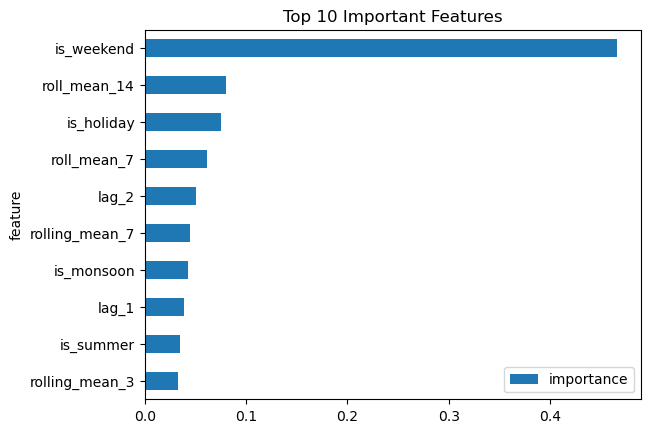

In [8]:

plt.figure()
feature_importance.head(10).plot(
    x='feature',
    y='importance',
    kind='barh'
)
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()


## 📈 Actual vs Predicted Demand

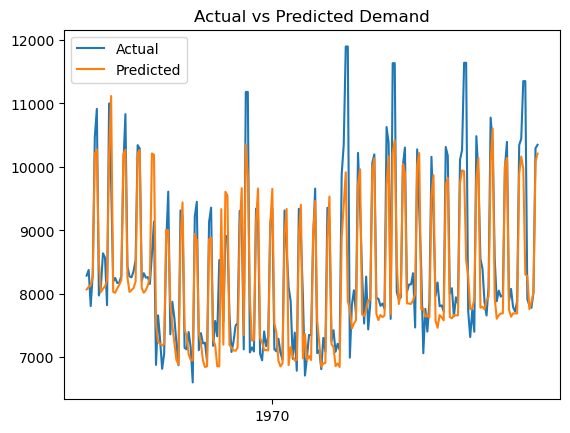

In [9]:

plt.figure()
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index, y_pred, label='Predicted')
plt.legend()
plt.title("Actual vs Predicted Demand")
plt.show()


## 💾 Save Predictions

In [10]:

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
results.to_csv('../reports/predictions.csv')



## 🧠 Business Insights

### 📌 Key Findings
- Model predicts demand with measurable error (MAE & RMSE)
- Recent trends and time-based features drive demand

### 📌 Business Impact
- Optimize inventory
- Reduce wastage
- Improve planning

### 📌 Conclusion
Model is useful for real-world demand forecasting.
